In [1]:
print("___")

___


## Machine Learning for Hyperspectral Image Analysis _ Part 2
### Sagar Lekhak, Phd Student, Year II.
### Chester F. Carlson Center for Imaging Science, Rochester Institute of Technology.

### Problem 1: Classification of Hyperspectral Image

#### 1.a. Perform all necessary exploratory data analysis (EDA) on the given dataset. Explain what are the important aspects of this dataset that needs to be explored before delving into solving the problem.

In [2]:
# Importing the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.io import loadmat


Dataset is stored as a dictionary: dict_keys(['__header__', '__version__', '__globals__', 'paviaU'])
Shape of Pavia dataset = (610, 340, 103)
Datatype = uint16
Is data stored in numpy array? Ans = True
Class type  = <class 'numpy.ndarray'>
Minimum value in the dataset = 0 and maximum value in the dataset = 8000
Mean of the data = 925.3249951783993, Std = 444.4264280637997


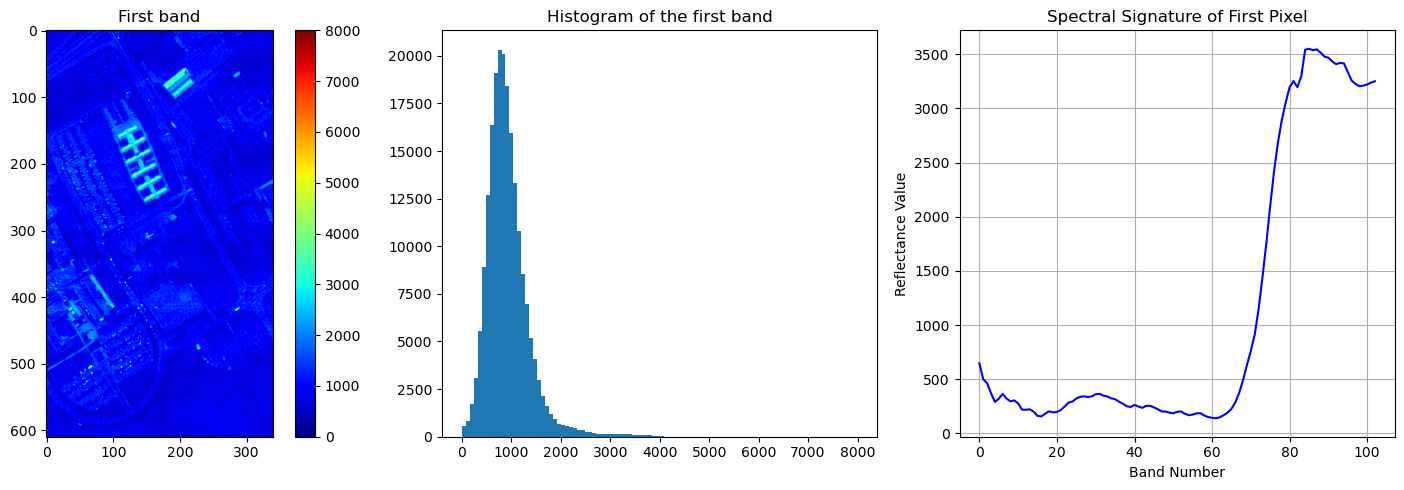

In [23]:
# Loading the data and checking some statistics.

# We can also use other kinds of libraries to load the data such as h5py or mat73, but we will use scipy to load the data.
# loadmat might not work if the data is stored in latest versions of matlab. In that case, we can use h5py or mat73 to load the data. In this case, we will use loadmat to load the data.
pavia_data = loadmat('paviaU.mat')
pavia_gt = loadmat('paviaU_gt.mat')

#.mat files are stored in such a way that the variable names are stored as keys in the dictionary. The keys in the dictionary are the variable names and the values are the data stored in the variable. We need to extract the data from the dictionary and store it in a variable.
#Our concern is the data stored in the variable 'paviaU'. We will extract the data from the dictionary and store it in a variable.
print(f"Dataset is stored as a dictionary: {pavia_data.keys()}")
paviaU = pavia_data['paviaU']  # Extracting the data from the dictionary and storing it in a variable.


print(f"Shape of Pavia dataset = {paviaU.shape}")
print(f"Datatype = {paviaU.dtype}")  #The data type is unsigned integer type of 16 bits. This means that the data is stored in the form of 16 bit unsigned integers.
print(f"Is data stored in numpy array? Ans = {isinstance(paviaU, np.ndarray)}")  #isinstance to check the data is numpy array or not
print(f"Class type  = {type(paviaU)}")  #Checking if the data is stored in the form of a numpy array or not.

# It means the data is stored in the form of a numpy array.
# Now we can visualize the data and do necessary exploratory data analysis as required.
#print(paviaU[:,:,0])  #Printing the first band of the data.

print(f"Minimum value in the dataset = {paviaU[:,:,0].min()} and maximum value in the dataset = {paviaU[:,:,0].max()}")  #Printing the minimum and maximum values of the first band of the data.
print(f"Mean of the data = {paviaU[:,:,0].mean()}, Std = {paviaU[:,:,0].std()}")  #Printing the mean and standard deviation of the first band of the data.
#print(paviaU[0,0,:]) #print the first pixel of the data.


# Create a figure with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Plot the first band of the data
axs[0].imshow(paviaU[:, :, 0], cmap='jet')
axs[0].set_title("First band")
fig.colorbar(axs[0].imshow(paviaU[:, :, 0], cmap='jet'), ax=axs[0])

# Plot the histogram of the first band of the data
axs[1].hist(paviaU[:, :, 0].flatten(), bins=100)
axs[1].set_title('Histogram of the first band')

# Plot the spectral signature of the first pixel
first_pixel = paviaU[0, 0, :]
axs[2].plot(first_pixel, linestyle='-', color='b')
axs[2].set_xlabel('Band Number')
axs[2].set_ylabel('Reflectance Value')
axs[2].set_title('Spectral Signature of First Pixel')
axs[2].grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

Blue band: 10, Wavelength: 481.96078431372547 nm
Green band: 23, Wavelength: 549.5098039215686 nm
Red band: 42, Wavelength: 648.2352941176471 nm
Red-edge band: 56, Wavelength: 720.9803921568628 nm
NIR band: 81, Wavelength: 850.8823529411765 nm


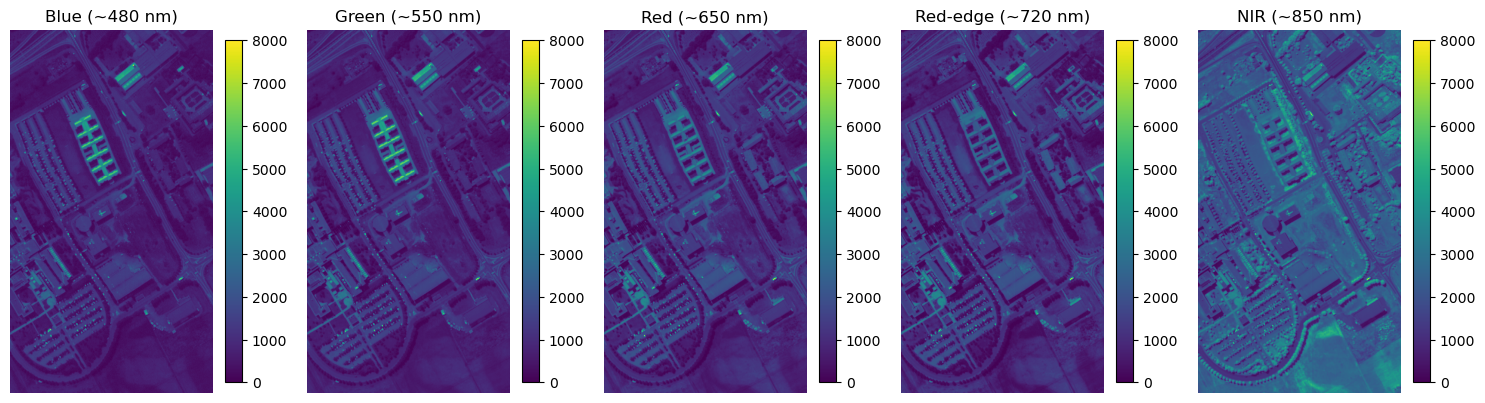

In [34]:

# Wavelength range and band count: Since it is provided that the sensor captures wavelengths from 430 nm to 960 nm with 103 bands with 5nm spacing.
start_wavelength = 430   # in nm
end_wavelength = 960     # in nm
band_count = 103

# Generate the wavelength values
wavelengths = np.linspace(start_wavelength, end_wavelength, band_count)

# Find the closest bands for each region
blue_band = np.argmin(np.abs(wavelengths - 480))      # Blue ~480 nm
green_band = np.argmin(np.abs(wavelengths - 550))     # Green ~550 nm
red_band = np.argmin(np.abs(wavelengths - 650))       # Red ~650 nm
red_edge_band = np.argmin(np.abs(wavelengths - 720))  # Red-edge ~720 nm
nir_band = np.argmin(np.abs(wavelengths - 850))       # NIR ~850 nm

print(f"Blue band: {blue_band}, Wavelength: {wavelengths[blue_band]} nm")
print(f"Green band: {green_band}, Wavelength: {wavelengths[green_band]} nm")
print(f"Red band: {red_band}, Wavelength: {wavelengths[red_band]} nm")
print(f"Red-edge band: {red_edge_band}, Wavelength: {wavelengths[red_edge_band]} nm")
print(f"NIR band: {nir_band}, Wavelength: {wavelengths[nir_band]} nm")

import matplotlib.pyplot as plt

# Extract bands
blue = paviaU[:, :, blue_band]
green = paviaU[:, :, green_band]
red = paviaU[:, :, red_band]
red_edge = paviaU[:, :, red_edge_band]
nir = paviaU[:, :, nir_band]

# Plot each band
bands = [blue, green, red, red_edge, nir]
titles = ['Blue (~480 nm)', 'Green (~550 nm)', 'Red (~650 nm)', 'Red-edge (~720 nm)', 'NIR (~850 nm)']

plt.figure(figsize=(15, 6))
for i, band in enumerate(bands):
    plt.subplot(1, 5, i + 1)
    plt.imshow(band)
    plt.colorbar(shrink = 0.6)
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [59]:
# Function to display RGB image
def display_rgb_image_with_contrast_stretching(image, title='RGB Image', pmin=2, pmax=98):
    """Display RGB image from hyperspectral data."""
    blue = image[:,:,10]
    green = image[:,:,23]
    red = image[:,:,42]
    rgb_image = np.stack((red, green, blue), axis=2)

    min_val = np.percentile(rgb_image, pmin)  # Compute 2nd percentile
    max_val = np.percentile(rgb_image, pmax)  # Compute 98th percentile

    stretched = (rgb_image- min_val) / (max_val - min_val)  # Normalize
    stretched = np.clip(stretched, 0, 1)  # Clip values to [0,1] range
    
    # # Normalize to 0-1 range
    # rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())
    # Display the RGB image
    plt.figure(figsize=(8, 8))
    plt.imshow(stretched)
    plt.title(title)
    #plt.axis('off')
    plt.show()

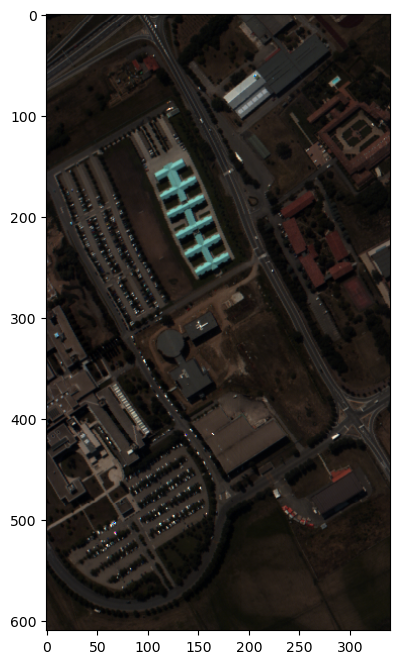

In [60]:
    rgb_image = np.stack((red, green, blue), axis=2)

    # Normalize to 0-1 range
    rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())
    #Display the RGB image
    plt.figure(figsize=(8, 8))
    plt.imshow(rgb_image)



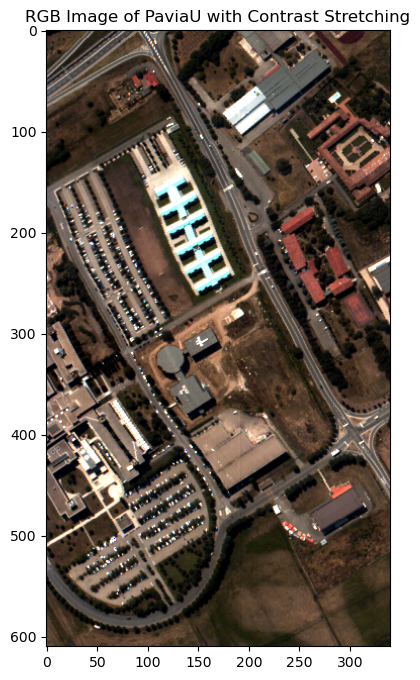

In [61]:
# Display the RGB image with contrast stretching
display_rgb_image_with_contrast_stretching(paviaU, title='RGB Image of PaviaU with Contrast Stretching')

In [53]:
#Load ground truth data
pavia_gt = loadmat('paviaU_gt.mat')
print(pavia_gt.keys())

dict_keys(['__header__', '__version__', '__globals__', 'paviaU_gt'])


In [54]:
# Extract the ground truth data
paviaU_gt = pavia_gt['paviaU_gt']

Text(0.5, 1.0, 'Ground Truth Data')

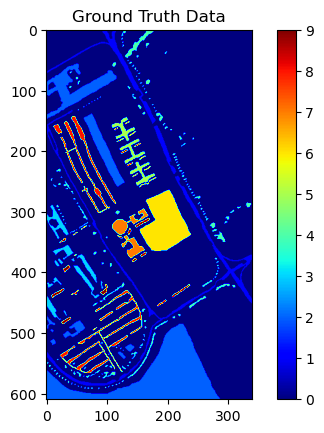

In [62]:
# Display the ground truth data
plt.imshow(paviaU_gt, cmap='jet')
plt.colorbar()
plt.title('Ground Truth Data')

In [63]:
paviaU_gt.shape

(610, 340)

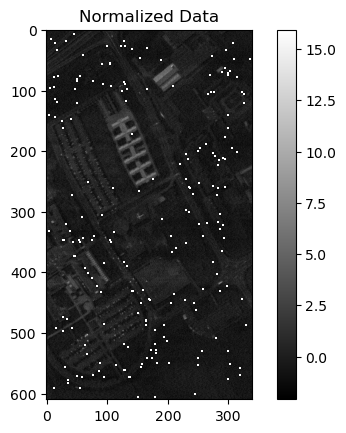

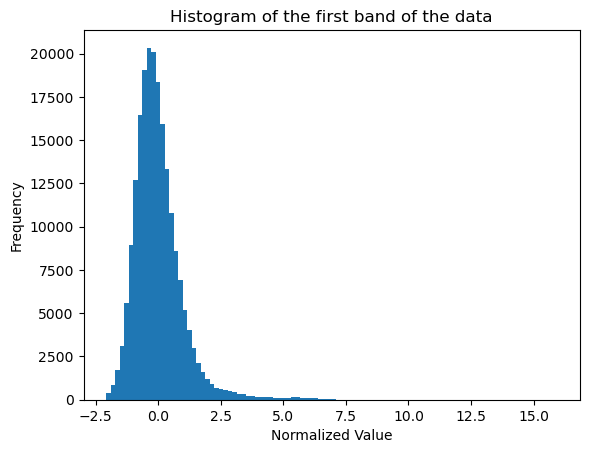

In [68]:
#

# Convert paviaU to a floating-point data type because original data is int type. we can't replace int with nan.
paviaU = paviaU.astype(float)

#Replace 0 values with NaN
paviaU[paviaU == 0] = np.nan

# Standardizing the data

#Computing the mean and standard deviation of the data
mean = np.nanmean(paviaU, axis=(0, 1)) #compute mean of data in each band
std = np.nanstd(paviaU, axis=(0, 1))  #compute std of data in each band
#Normalizing the data
paviaU = (paviaU - mean) / std  #normalizing the data so that each band has mean 0 and std 1

plt.imshow(paviaU[:,:,0], cmap='gray')  #Plotting the first band of the data.
plt.colorbar()
plt.title('Normalized Data')
plt.show()

plt.hist(paviaU[:,:,0].flatten(), bins = 100)  #Plotting the histogram of the first band of the data.
plt.title('Histogram of the first band of the data')
plt.xlabel('Normalized Value')
plt.ylabel('Frequency')
plt.show()




In [78]:
import pandas as pd
# Reshape to (samples, bands)
samples = paviaU.reshape(-1, paviaU.shape[-1])

# Convert to DataFrame and compute correlation matrix because numpy cannot handle nan values while computing correlation matrix.
df = pd.DataFrame(samples)
correlation_matrix = df.corr()
#print(correlation_matrix)

In [77]:
# Didn't use seaborn because it was not compatible with the current version of matplotlib.
# Plotting the correlation matrix
# import seaborn as sns  # For better heatmap visualization
#
# plt.figure(figsize=(12, 10))
# sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, cbar=True)
# plt.title('Correlation Matrix of Hyperspectral Bands')
# plt.xlabel('Bands')
# plt.ylabel('Bands')
# plt.show()


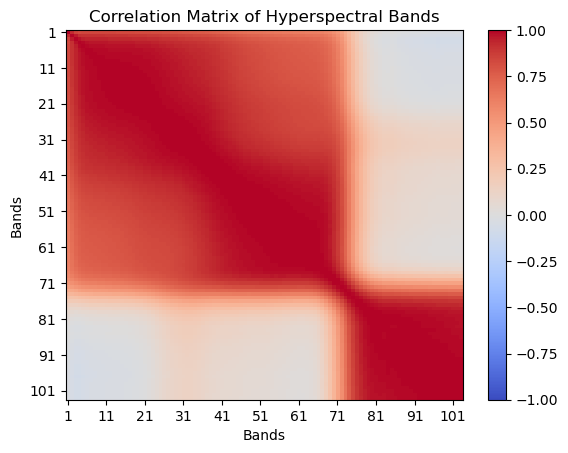

In [76]:
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar()
plt.title('Correlation Matrix of Hyperspectral Bands')
plt.xlabel('Bands')
plt.ylabel('Bands')
plt.xticks(ticks=np.arange(0, 103, 10), labels=np.arange(1, 104, 10))
plt.yticks(ticks=np.arange(0, 103, 10), labels=np.arange(1, 104, 10))
plt.show()

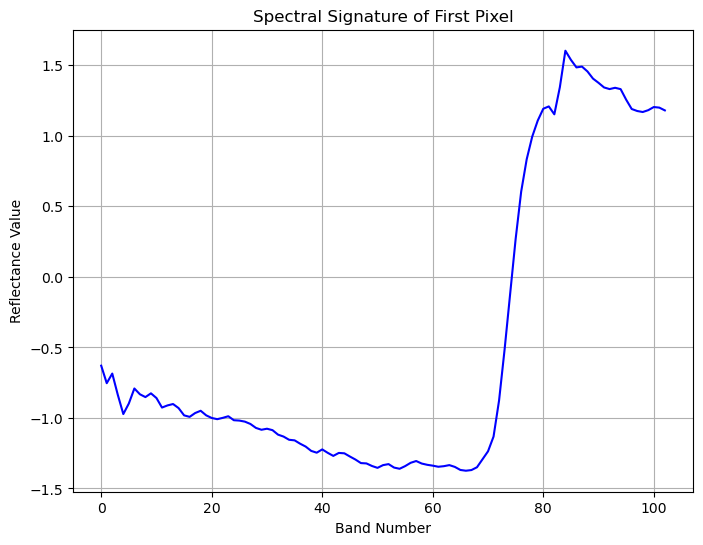

In [79]:
# Extract the first pixel (all bands)
first_pixel = paviaU[0, 0, :]

# Plot the spectral signature
plt.figure(figsize=(8, 6))
plt.plot(first_pixel, linestyle='-', color='b')
plt.xlabel('Band Number')
plt.ylabel('Reflectance Value')
plt.title('Spectral Signature of First Pixel')
plt.grid(True)
plt.show()

#### Comments: 1.b.:
The dataset is a hyperspectral image of Pavia University, Italy. It has 103 bands and the spatial resolution is 610x340 pixels. The ground truth data is also provided which contains the class labels for each pixel in the image. The classes are as follows:
- 1. Asphalt
- 2. Meadows
- 3. Gravel
- 4. Trees
- 5. Painted metal sheets
- 6. Bare Soil
- 7. Bitumen
- 8. Self-Blocking Bricks
- 9. Shadows

As seen in the dataset above, the dataset is in digital counts. So, we need to normalize or standardize the data for each band. The dataset also has 'no data' or '0' values in it, which represent shadow regions. They can alter or skew the distribution. So, before normalizing the data we should handle such values. So, we replaced such values with nan.

- Why not min max normalization?
- Min-max normalization scales the data to a fixed range, typically [0, 1]. This can be problematic if the data has outliers or if the distribution is not uniform.
- For SVM or PCA: Standardization is usually better. It centers the data around 0 and scales it based on the standard deviation, making it more robust to outliers.
- For Neural Networks, kNN: Min-max normalization is often preferred.

- Correlation Heatmap:
As seen in the correlation matrix of the data, there are some bands that are highly correlated with each other. This means that these bands carry similar information. So, we can remove some of the bands that are highly correlated with each other to reduce the dimensionality of the data. This will also help in reducing the computational cost and memory requirements.

For hyperspectral image classification tasks like the Pavia University dataset, removing highly correlated bands or reducing dimensionality is often a crucial preprocessing step. This is because hyperspectral data typically contains hundreds of spectral bands, many of which are highly correlated and redundant. These redundancies can lead to increased computational complexity, overfitting, and reduced classification performance.

In such case, we can proceed with the following steps:
1. **Correlation Analysis**: Calculate the correlation matrix of the hyperspectral data to identify highly correlated bands.
2. **Band Selection**: Remove bands that are highly correlated (e.g., correlation coefficient > 0.9) to reduce redundancy.
3. **Dimensionality Reduction**: Apply techniques like PCA, t-SNE, LDA, etc.  to further reduce the dimensionality while retaining most of the variance in the data.
4. **Feature Selection**: (haven't discussed yet in course) Use feature selection methods to identify the most informative bands for classification.
5. **Model Training**: Train the classification model on the reduced set of bands.
6. **Evaluation**: Evaluate the model's performance using metrics like accuracy, F1-score, and confusion matrix.
7. **Visualization**: Visualize the classification results to understand the model's performance and identify areas for improvement.
8. **Iterative Refinement**: Based on the evaluation, iteratively refine the band selection and preprocessing steps to optimize classification performance.



In [80]:
#Checking the number of pixels in each class
# Extract unique classes and their counts
unique_classes, counts = np.unique(paviaU_gt, return_counts=True)
# Create a dictionary to store class counts
class_counts = dict(zip(unique_classes, counts))
# Print the class counts
for class_label, count in class_counts.items():
    print(f"Class {class_label}: {count} pixels")


Class 0: 164624 pixels
Class 1: 6631 pixels
Class 2: 18649 pixels
Class 3: 2099 pixels
Class 4: 3064 pixels
Class 5: 1345 pixels
Class 6: 5029 pixels
Class 7: 1330 pixels
Class 8: 3682 pixels
Class 9: 947 pixels


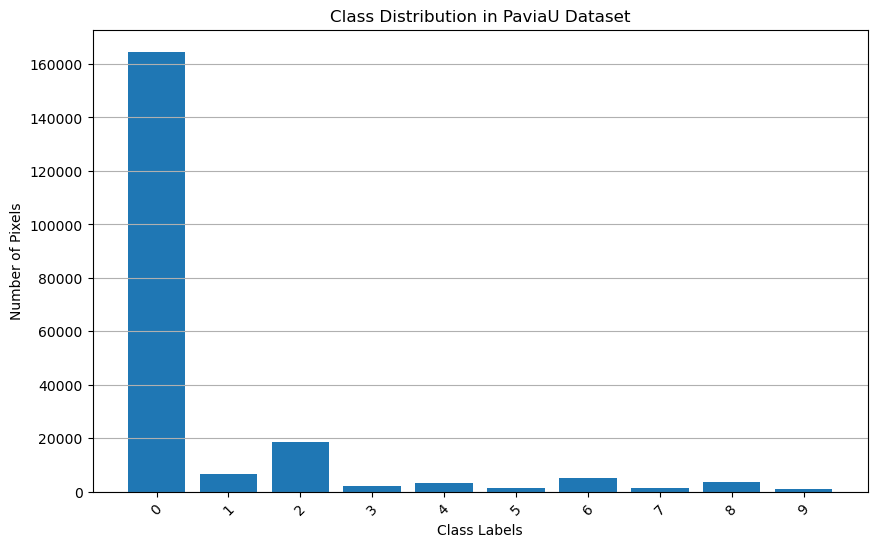

In [81]:
# Plotting the class distribution
plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel('Class Labels')
plt.ylabel('Number of Pixels')
plt.title('Class Distribution in PaviaU Dataset')
plt.xticks(list(class_counts.keys()), rotation=45)
plt.grid(axis='y')
plt.show()


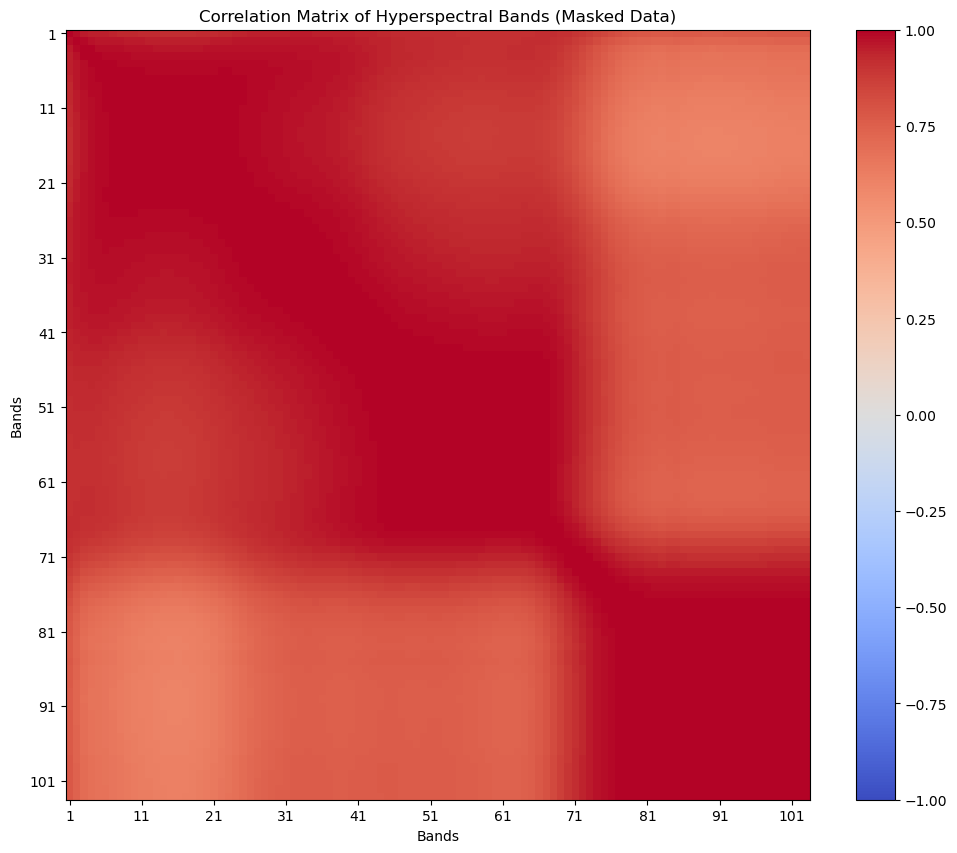

In [89]:
# Note: as mentioned in question, you would need to dump class 0 in your lables, your total number of samples should be 42776.
#
# Create a mask for non-zero classes
mask = paviaU_gt != 0
# Apply the mask to the hyperspectral data
paviaU_masked = np.zeros_like(paviaU)
paviaU_masked[mask] = paviaU[mask]  #The resulting paviaU_masked is a masked version of the hyperspectral data, where:
# Only the pixels with valid class labels (non-zero labels in paviaU_gt) retain their original spectral values.
# All other pixels (unlabeled or background) are set to 0

# Reshape the masked data to (samples, bands)
samples_masked = paviaU_masked.reshape(-1, paviaU.shape[-1])
# Create a DataFrame from the masked samples
df_masked = pd.DataFrame(samples_masked)
# Compute the correlation matrix for the masked data
correlation_matrix_masked = df_masked.corr()
# Plot the correlation matrix for the masked data
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix_masked, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar()
plt.title('Correlation Matrix of Hyperspectral Bands (Masked Data)')
plt.xlabel('Bands')
plt.ylabel('Bands')
plt.xticks(ticks=np.arange(0, 103, 10), labels=np.arange(1, 104, 10))
plt.yticks(ticks=np.arange(0, 103, 10), labels=np.arange(1, 104, 10))
plt.show()


In [106]:
mask.shape

(610, 340)

In [107]:
paviaU_masked.shape

(610, 340, 103)

In [108]:
samples_masked.shape

(207400, 103)

In [90]:
# Check the number of pixels in each class after masking
# Extract unique classes and their counts
unique_classes_masked, counts_masked = np.unique(paviaU_gt[mask], return_counts=True)
# Create a dictionary to store class counts
class_counts_masked = dict(zip(unique_classes_masked, counts_masked))
# Print the class counts
for class_label, count in class_counts_masked.items():
    print(f"Class {class_label}: {count} pixels")


Class 1: 6631 pixels
Class 2: 18649 pixels
Class 3: 2099 pixels
Class 4: 3064 pixels
Class 5: 1345 pixels
Class 6: 5029 pixels
Class 7: 1330 pixels
Class 8: 3682 pixels
Class 9: 947 pixels


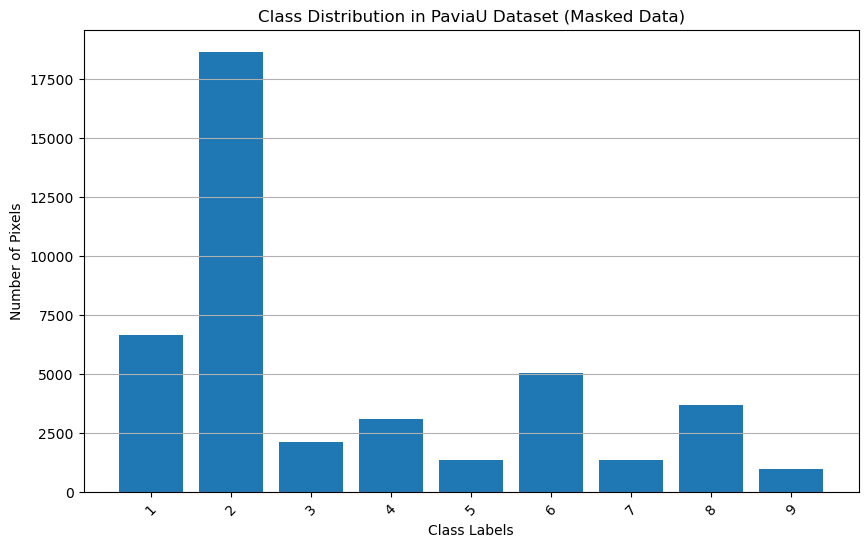

In [91]:
# Plotting the class distribution after masking
plt.figure(figsize=(10, 6))
plt.bar(class_counts_masked.keys(), class_counts_masked.values())
plt.xlabel('Class Labels')
plt.ylabel('Number of Pixels')
plt.title('Class Distribution in PaviaU Dataset (Masked Data)')
plt.xticks(list(class_counts_masked.keys()), rotation=45)
plt.grid(axis='y')
plt.show()


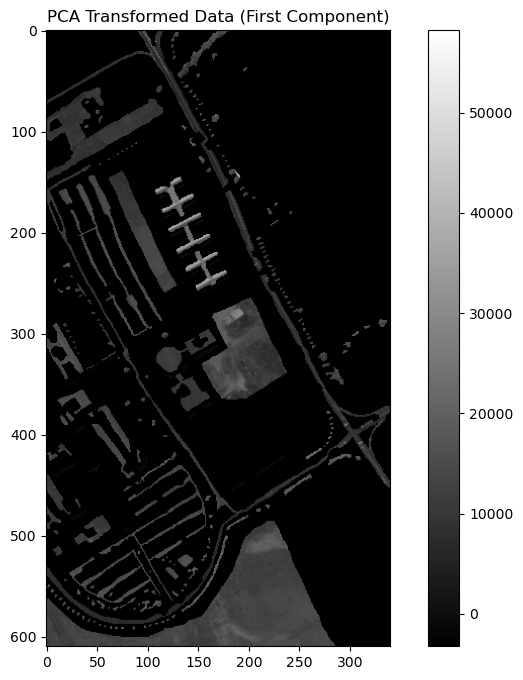

In [92]:
# Apply PCA to the masked data
from sklearn.decomposition import PCA
# Initialize PCA with the desired number of components
n_components = 10
pca = PCA(n_components=n_components)
# Fit PCA to the masked data
pca.fit(samples_masked)
# Transform the masked data using PCA
samples_pca = pca.transform(samples_masked)
# Reshape the PCA-transformed data to the original spatial dimensions
paviaU_pca = samples_pca.reshape(paviaU.shape[0], paviaU.shape[1], n_components)
# Display the PCA-transformed data
plt.figure(figsize=(10, 8))
plt.imshow(paviaU_pca[:, :, 0], cmap='gray')
plt.colorbar()
plt.title('PCA Transformed Data (First Component)')
plt.show()


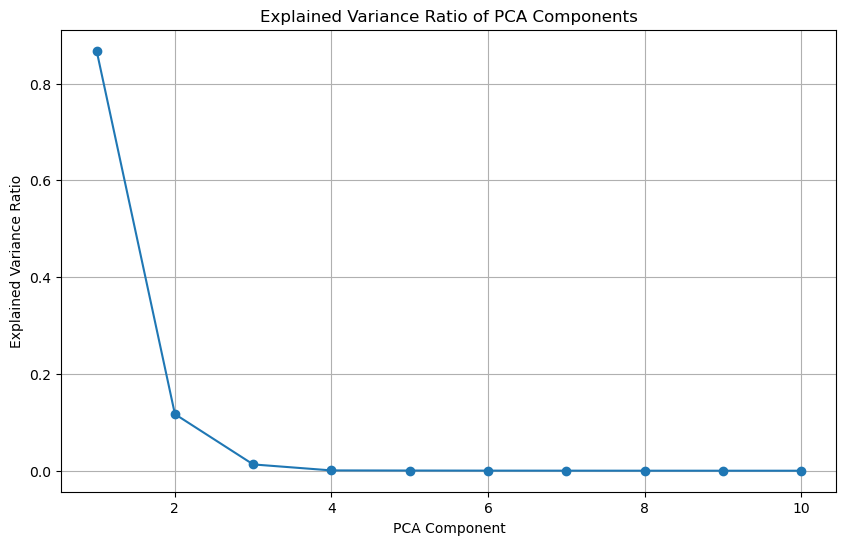

In [93]:
# Plot the explained variance ratio of PCA components
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, n_components+1), pca.explained_variance_ratio_, marker='o')
plt.xlabel('PCA Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of PCA Components')
plt.grid()
plt.show()


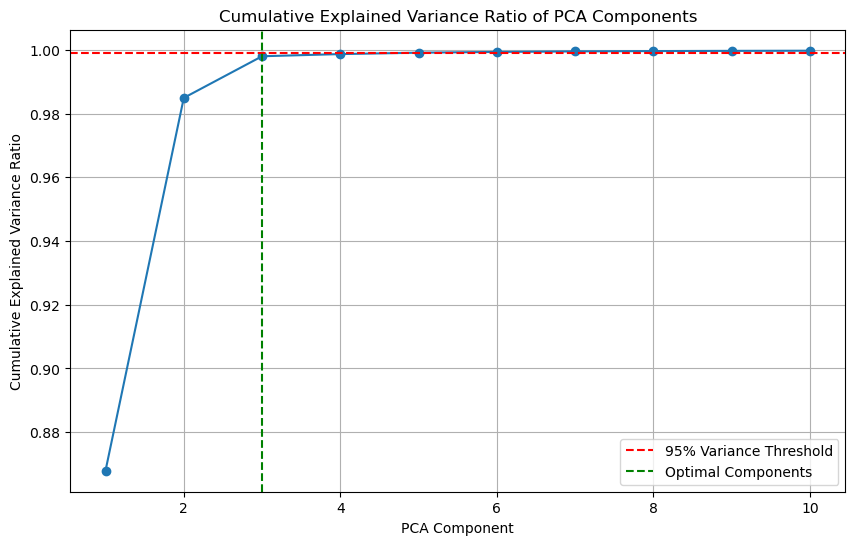

In [99]:
# Plot the cumulative explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, n_components+1), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('PCA Component')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio of PCA Components')
plt.grid()
plt.axhline(y=0.999, color='r', linestyle='--', label='95% Variance Threshold')
plt.axvline(x=3, color='g', linestyle='--', label='Optimal Components')
plt.legend()
plt.show()


In [102]:
# Plot the first 10 PCA components as grayscale images
def plot_pca_components(pca_data, n_components=10, title='PCA Components'):
    """Plot the first n PCA components as grayscale images."""
    plt.figure(figsize=(15, 10))
    for i in range(n_components):
        plt.subplot(2, 5, i + 1)
        plt.imshow(pca_data[:, :, i], cmap='gray')
        plt.colorbar()
        plt.title(f'PCA Component {i+1}')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

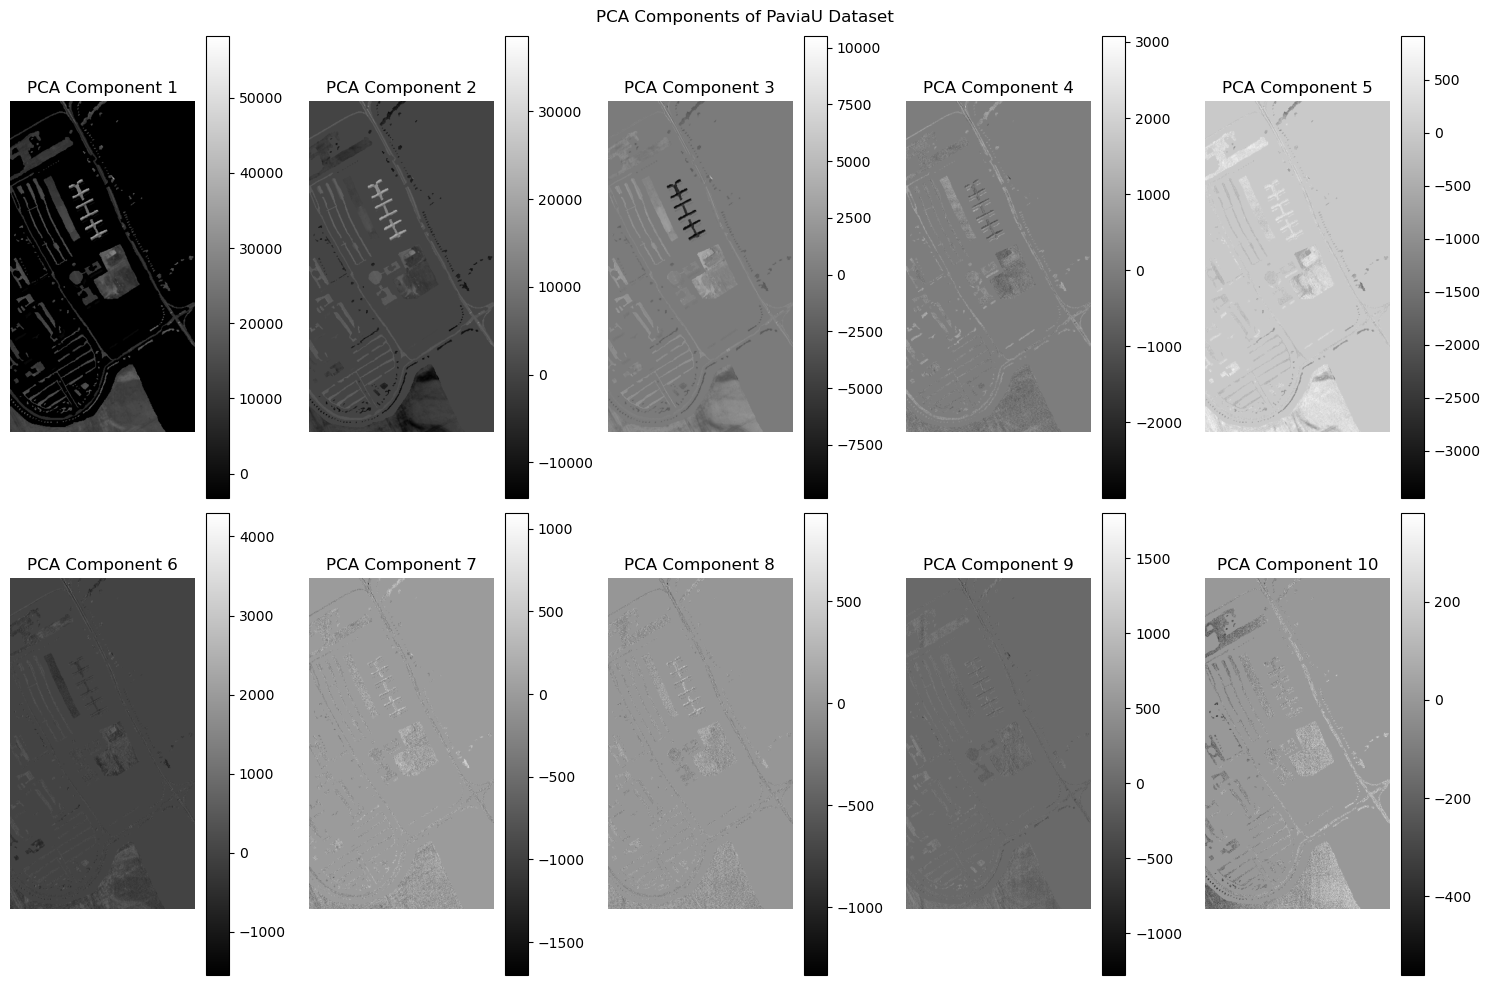

In [103]:
# Plot the PCA components
plot_pca_components(paviaU_pca, n_components=10, title='PCA Components of PaviaU Dataset')